<h2 style="color:#08519c; border-bottom:3px solid #08519c; padding-bottom:4px; margin-top:15px;">
  5. Visualizations
</h2>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data_cleaned = pd.read_csv("data_cleaned.csv")

### <span style="color:#08519c">Section 1: Roles & Job Titles</span>

#### <font color='#0891b2' > 1. Average Salary by Job Title

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This chart highlights how salaries differ across job titles.

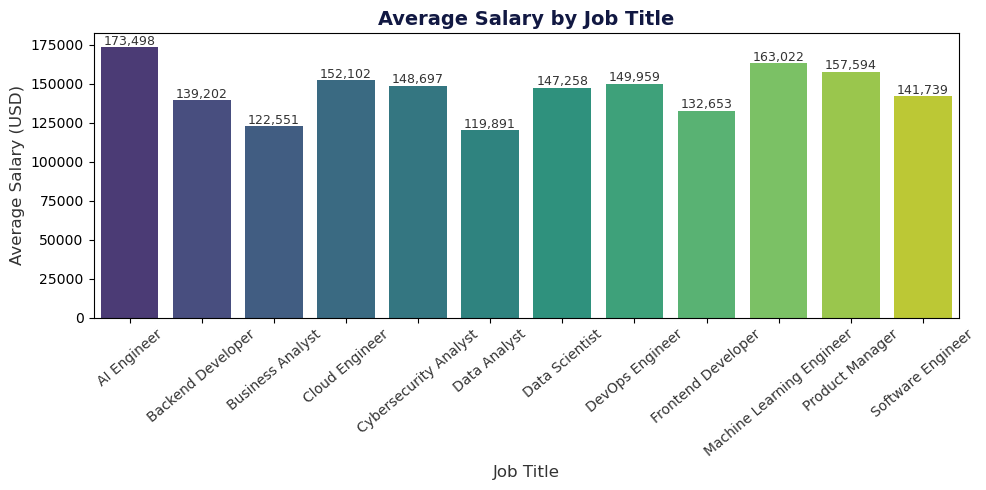

In [5]:
custom_palette = [ "#46327E", "#3F4788", "#365C8D", "#2E6E8E", 
                   "#277F8E", "#21918C", "#1FA187", "#2DB27D", 
                   "#4AC16D", "#73D056", "#A0DA39", "#D0E11C"] 

# Average salary by job title
job_salary = data_cleaned.groupby('job_title', observed=False)['salary'].mean().reset_index()


plt.figure(figsize=(10,5))
sns.barplot(x='job_title', y='salary', hue='job_title',
            data=job_salary, palette=custom_palette, legend=False)

plt.title("Average Salary by Job Title", fontsize=14, color='#111842', weight='bold')
plt.xticks(rotation=40, fontsize=10, color='#333333')
plt.xlabel("Job Title", fontsize=12, color='#333333')
plt.ylabel("Average Salary (USD)", fontsize=12, color='#333333')

# Adding labels
for index, row in job_salary.iterrows():
    plt.text(index, row.salary + 1500, f"{int(row.salary):,}",
             ha='center', fontsize=9, color='#333333')

plt.tight_layout()
plt.show()

#### 💡 Insight
- AI Engineers and Machine Learning Engineers lead salary averages.  
- Data Analysts and Business Analysts earn comparatively less.  

#### <font color='#0891b2' > 2. Salary Spread by Job Title

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This boxplot shows the variation in salaries within each job title.

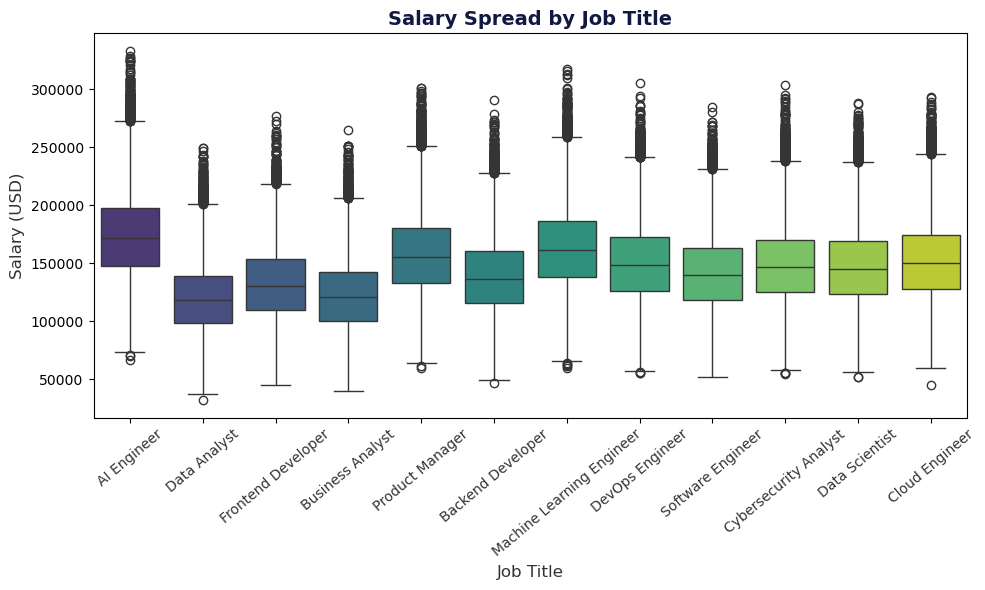

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(x='job_title', y='salary', hue='job_title',
            data=data_cleaned, palette=custom_palette, legend=False)

plt.title("Salary Spread by Job Title", fontsize=14, color='#111842', weight='bold')
plt.xticks(rotation=40, fontsize=10, color='#333333')
plt.xlabel("Job Title", fontsize=12, color='#333333')
plt.ylabel("Salary (USD)", fontsize=12, color='#333333')
plt.tight_layout()
plt.show()

#### 💡 Insight
- AI Engineers and Machine Learning Engineers show the highest median salaries, with wide spreads indicating strong earning potential at senior levels.  
- Data Analysts and Business Analysts have lower medians and narrower ranges, reflecting more consistent but modest pay scales.  

### <span style="color:#08519c">Section 2: Education & Role Interaction</span>

#### <font color='#0891b2' > 3. Salary Distribution by Education Level   

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This violin plot shows how salaries vary across education levels.

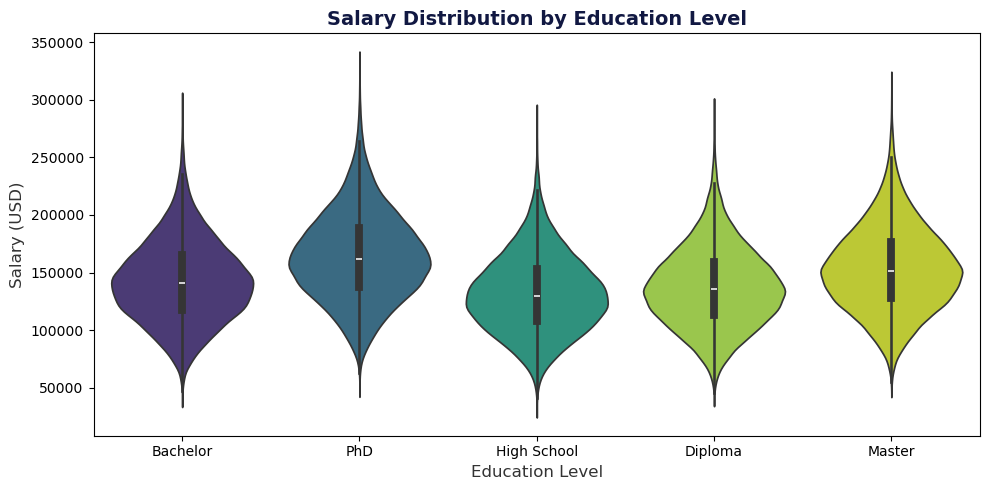

In [9]:
plt.figure(figsize=(10,5))
sns.violinplot(x='education_level', y='salary', data=data_cleaned,
               hue='education_level',
               palette=["#46327E", "#2E6E8E", "#1FA187", "#A0DA39", "#D0E11C"],
               legend=False)

plt.title("Salary Distribution by Education Level", fontsize=14, color='#111842', weight='bold')
plt.xlabel("Education Level", fontsize=12, color='#333333')
plt.ylabel("Salary (USD)", fontsize=12, color='#333333')
plt.tight_layout()
plt.show()

#### 💡 Insight
- Salaries generally increase with higher education levels.  
- Master's and PhD holders show the strongest earning potential.  

#### <font color='#0891b2' > 4. Salary by Education × Job Title   

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This set of boxplots compares salaries by education level within each job title.

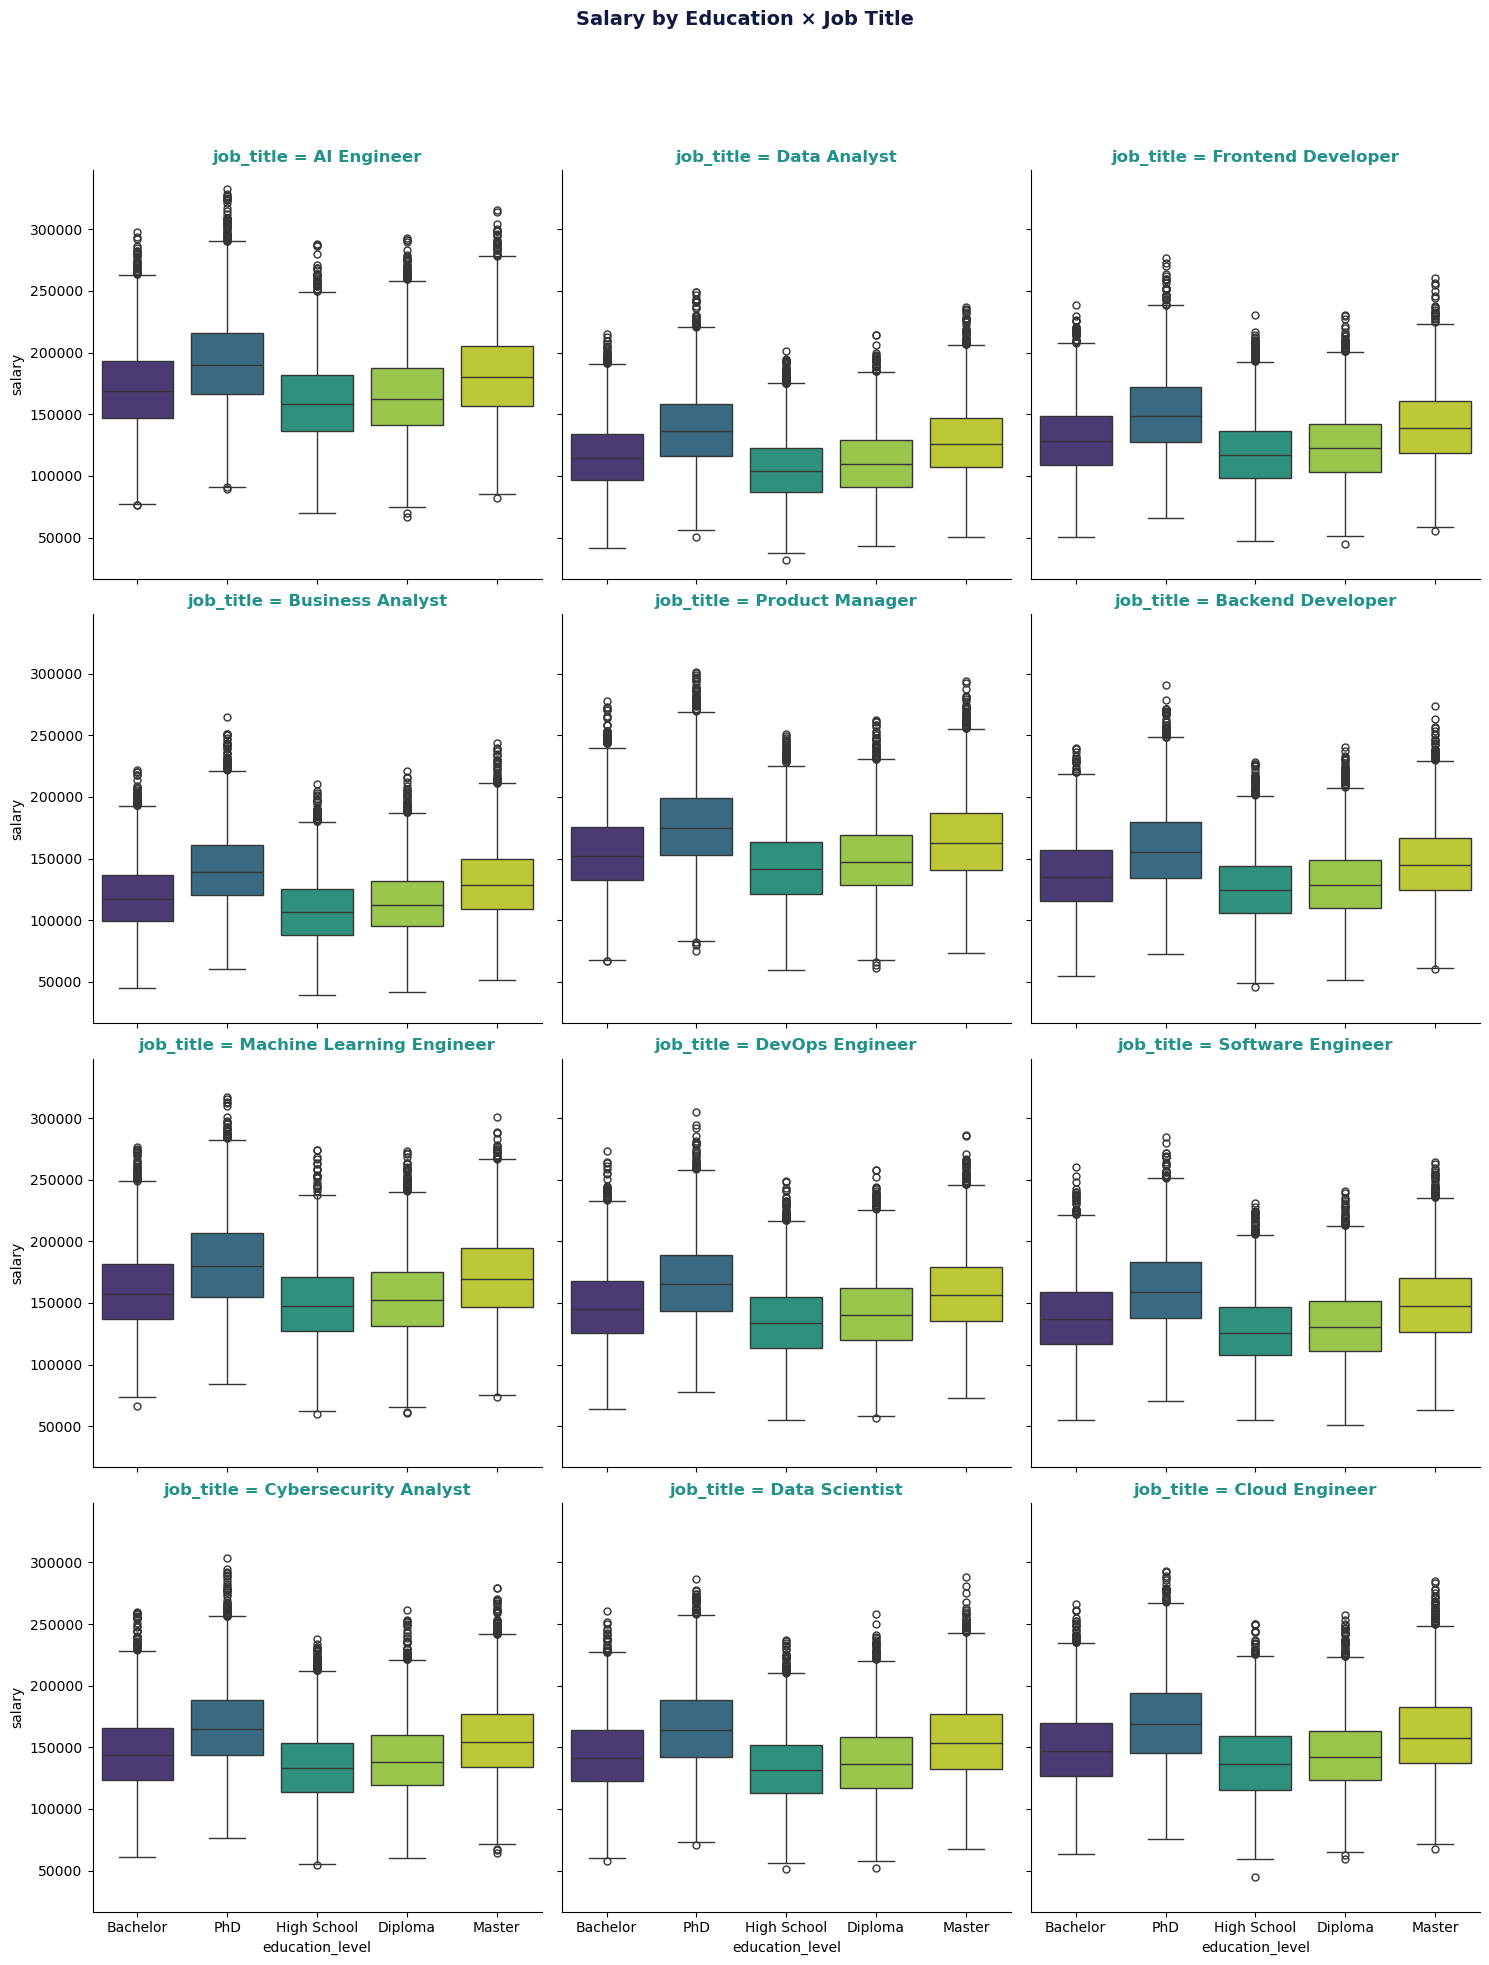

In [10]:
g = sns.catplot(x="education_level", y="salary", col="job_title",
                data=data_cleaned, kind="box", col_wrap=3,
                hue="education_level", palette=["#46327E", "#2E6E8E", "#1FA187", "#A0DA39", "#D0E11C"], legend=False)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Salary by Education × Job Title", fontsize=14, color='#111842', weight='bold')
for ax in g.axes.flat:
    ax.set_title(ax.get_title(), color="#21918C", fontsize=12, weight='bold')
plt.show()

#### 💡 Insight
- Across all job titles, higher education consistently leads to higher salaries.  
- Master's and PhD holders earn more than those with Bachelor's, Diploma, or High School qualifications.  
- The effect is visible in both technical and non‑technical roles, confirming education level as a strong driver of compensation across the board.  

### <span style="color:#08519c">Section 3: Career Growth Factors</span>

#### <font color='#0891b2' > 5. Salary Trend by Years of Experience 

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This line chart shows how average salary grows with more years of experience.

In [11]:
exp_salary = data_cleaned[['experience_years', 'salary']]

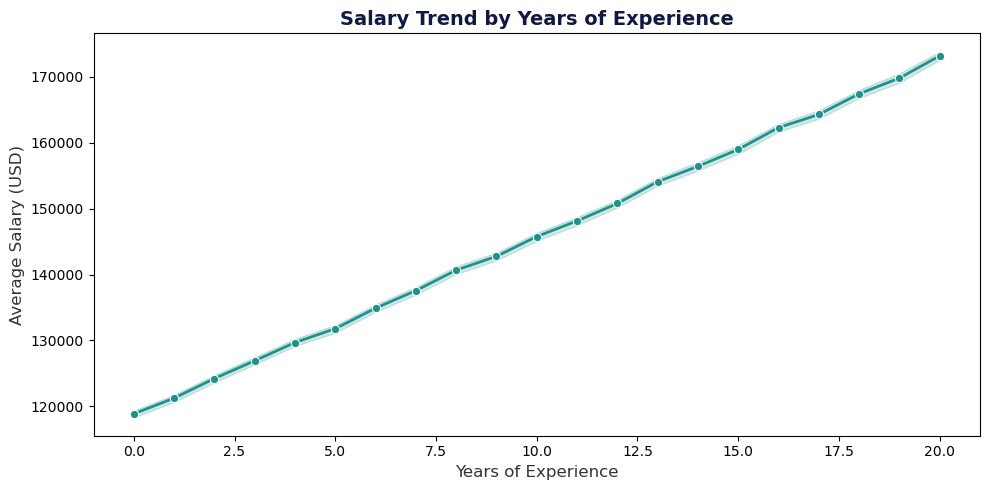

In [12]:
plt.figure(figsize=(10,5))
sns.lineplot(x='experience_years', y='salary',
             data=exp_salary,
             color="#21918C",   
             linewidth=2, marker="o")

plt.title("Salary Trend by Years of Experience", fontsize=14, color='#111842', weight='bold')
plt.xlabel("Years of Experience", fontsize=12, color='#333333')
plt.ylabel("Average Salary (USD)", fontsize=12, color='#333333')
plt.tight_layout()
plt.show()

#### 💡 Insight
- Salaries increase steadily with years of experience, showing a clear positive correlation between professional tenure and compensation.  
- The upward trend highlights the strong value of long‑term expertise, with significant gains after 10+ years in the field.  

#### <font color='#0891b2' >6. Average Salary vs Skills Count

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This chart shows how salary changes with the number of skills.

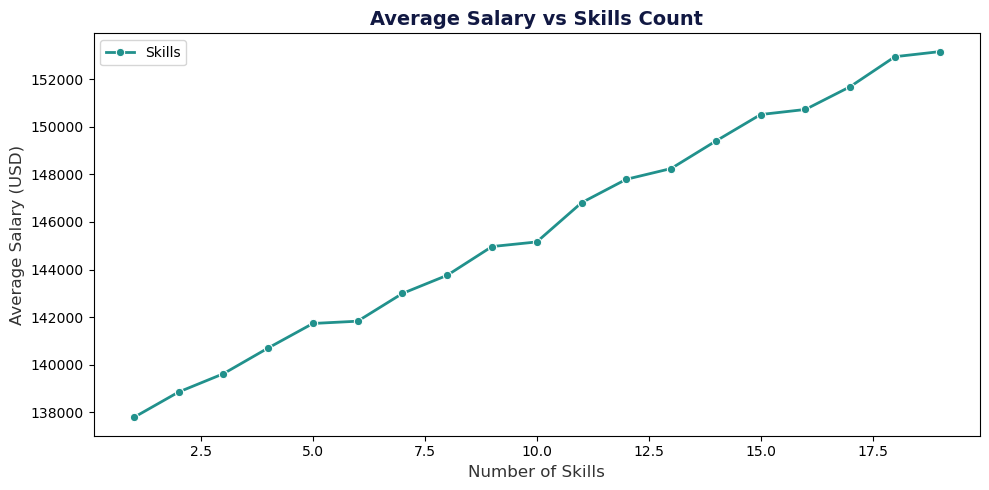

In [13]:
# Group by skills_count and calculate average salary
skills_avg = data_cleaned.groupby('skills_count', observed=False)['salary'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='skills_count', y='salary', data=skills_avg,
             color="#21918C", linewidth=2, marker="o", label="Skills")

plt.title("Average Salary vs Skills Count", fontsize=14, color='#111842', weight='bold')
plt.xlabel("Number of Skills", fontsize=12, color='#333333')
plt.ylabel("Average Salary (USD)", fontsize=12, color='#333333')
plt.legend()
plt.tight_layout()
plt.show()

#### 💡 Insight
- Average salary rises as the number of skills increases, showing a clear positive correlation between skill acquisition and earning potential.  
- Professionals with a broader skill set consistently command higher pay, emphasizing the importance of continuous learning and diversification.  

#### <font color='#0891b2' >7. Average Salary vs Certifications Count 

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This chart shows how certifications impact average salary.

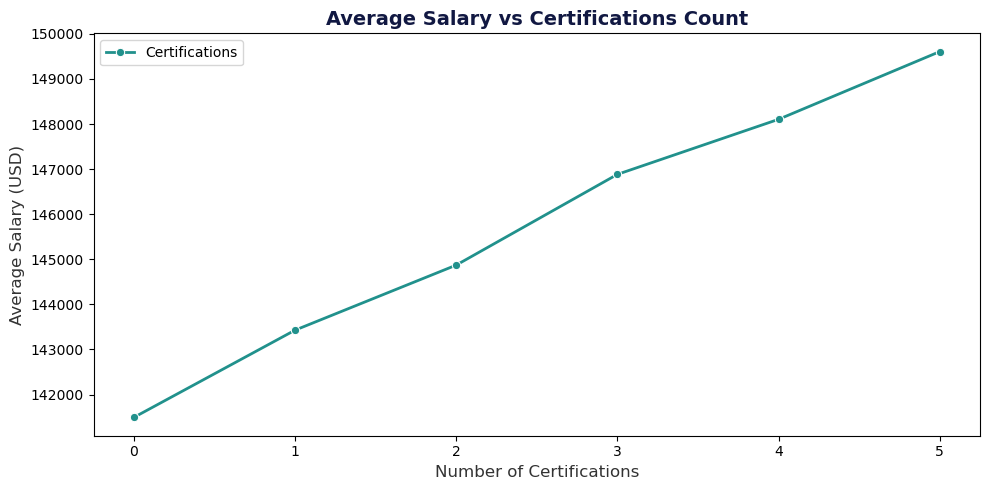

In [14]:
# Group by certifications_count and calculate average salary
certs_avg = data_cleaned.groupby('certifications', observed=False)['salary'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='certifications', y='salary', data=certs_avg,
             color="#21918C", linewidth=2, marker="o", label="Certifications")

plt.title("Average Salary vs Certifications Count", fontsize=14, color='#111842', weight='bold')
plt.xlabel("Number of Certifications", fontsize=12, color='#333333')
plt.ylabel("Average Salary (USD)", fontsize=12, color='#333333')
plt.legend()
plt.tight_layout()
plt.show()

#### 💡 Insight
- Average salary increases with the number of certifications, showing a clear positive correlation between professional credentials and compensation.  
- Even a small number of certifications provides a measurable boost, while multiple certifications strengthen earning potential further.  

### <span style="color:#08519c">Section 4: Industry & Company Context</span>

#### <font color='#0891b2' >8. Average vs Max Salary by Industry  

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This chart compares average and maximum salaries across industries.

In [15]:
industry_stats = data_cleaned.groupby('industry', observed=False)['salary'].agg(
    average_salary='mean',
    max_salary='max'
).reset_index()

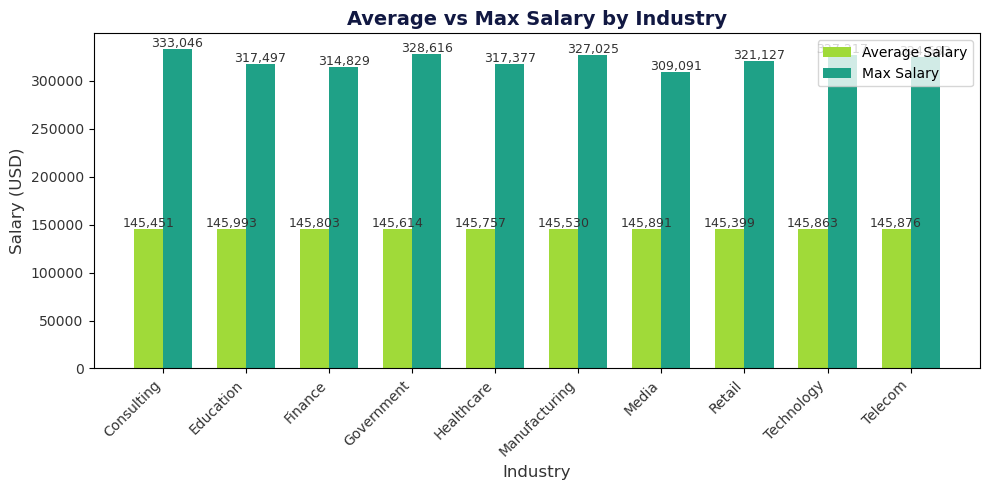

In [16]:
x = np.arange(len(industry_stats['industry']))  
width = 0.35  

plt.figure(figsize=(10,5))

# Average salary bars
plt.bar(x - width/2, industry_stats['average_salary'], width,
        color="#A0DA39", label="Average Salary")

# Max salary bars
plt.bar(x + width/2, industry_stats['max_salary'], width,
        color="#1FA187", label="Max Salary")

# Titles and labels
plt.title("Average vs Max Salary by Industry", fontsize=14, color='#111842', weight='bold')
plt.xlabel("Industry", fontsize=12, color='#333333')
plt.ylabel("Salary (USD)", fontsize=12, color='#333333')
plt.xticks(x, industry_stats['industry'], rotation=45, ha='right', color='#333333')
plt.yticks(color='#333333')
plt.legend()

# Add value labels
for i, val in enumerate(industry_stats['average_salary']):
    plt.text(i - width/2, val + 2000, f"{int(val):,}", ha='center', fontsize=9, color='#333333')
for i, val in enumerate(industry_stats['max_salary']):
    plt.text(i + width/2, val + 2000, f"{int(val):,}", ha='center', fontsize=9, color='#333333')

plt.tight_layout()
plt.show()

#### 💡 Insight
- Across industries, average salaries remain fairly consistent, but maximum salaries vary widely.  
- Consulting, Government, Technology, and Manufacturing show the highest maximum salaries.  
- These sectors highlight opportunities for top performers to earn well above the industry average.  

#### <font color='#0891b2' >9. Average Salary by Company Size   

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This chart shows how company size influences average salary.

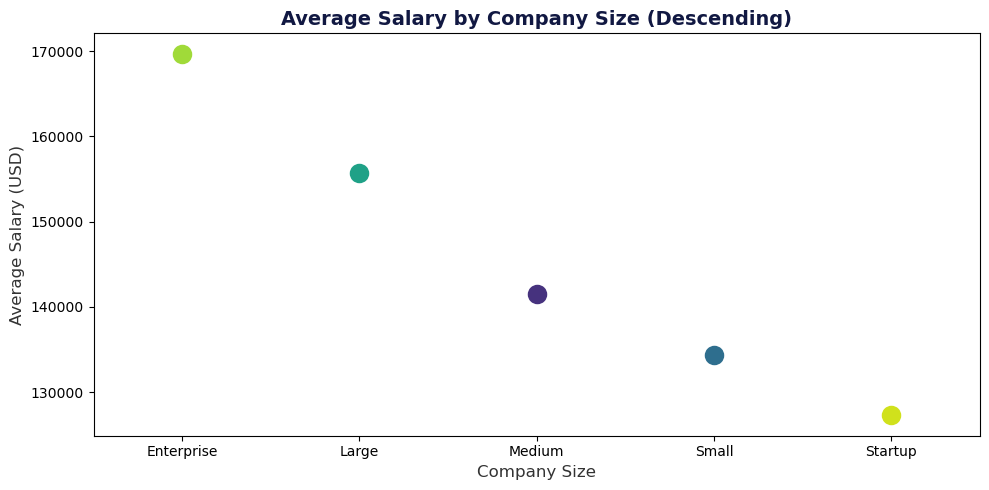

In [20]:
# Calculate average salary by company size
order = (
    data_cleaned.groupby("company_size")["salary"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10,5))
sns.pointplot(
    x='company_size', y='salary', hue='company_size',
    data=data_cleaned,
    order=order,  
    palette=["#46327E", "#2E6E8E", "#1FA187", "#A0DA39", "#D0E11C"],
    dodge=False,
    markers='o',
    linestyles='',
    legend=False
)

plt.setp(plt.gca().lines, markersize=12)
plt.setp(plt.gca().collections, sizes=[200])
plt.title("Average Salary by Company Size (Descending)", fontsize=14, color='#111842', weight='bold')
plt.xlabel("Company Size", fontsize=12, color='#333333')
plt.ylabel("Average Salary (USD)", fontsize=12, color='#333333')
plt.tight_layout()
plt.show()

#### 💡 Insight
- Larger companies consistently offer higher average salaries.  
- Enterprise organizations lead compensation levels.  
- Startups and small companies provide lower pay on average.  

### <span style="color:#08519c">Section 5: Work Mode & Location</span>

#### <font color='#0891b2' >10. Salary by Work Mode across Locations    

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This set of barplots compares salaries by work mode within each location.

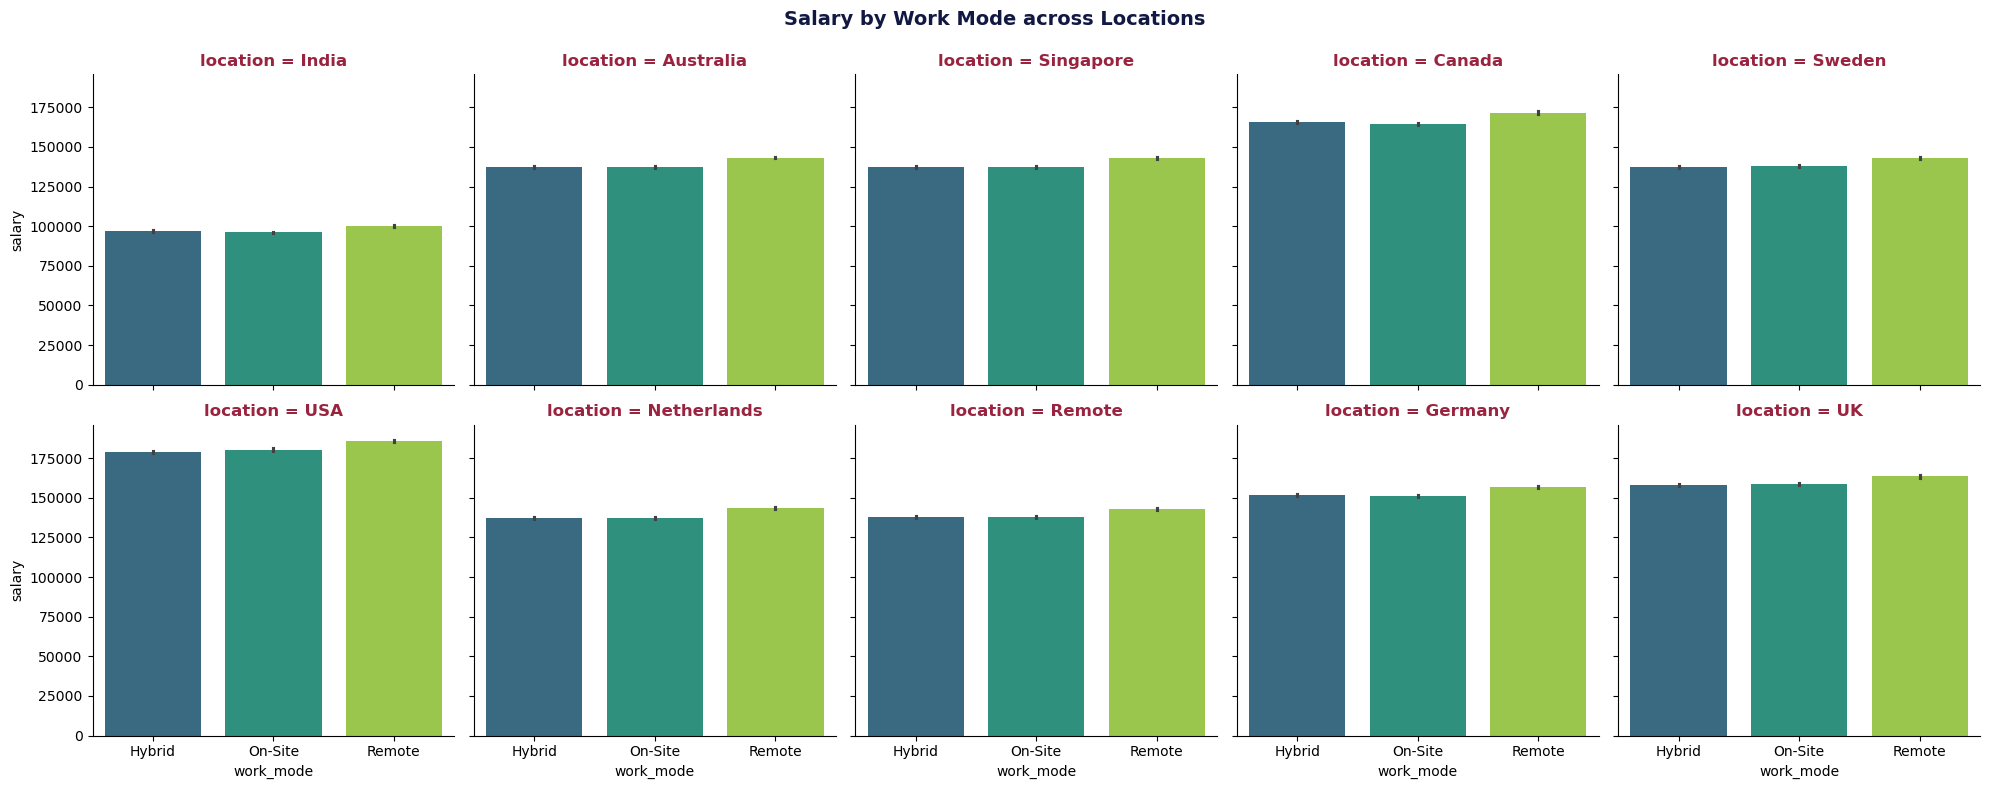

In [22]:
g = sns.catplot(
    x='work_mode', y='salary',
    hue='work_mode',               
    col='location', col_wrap=5,  
    data=data_cleaned, kind='bar',        
    palette=["#2E6E8E", "#1FA187", "#A0DA39"], 
    height=4, aspect=1,
    legend=False                    
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Salary by Work Mode across Locations", fontsize=14, color='#111842', weight='bold')

# Customize subplot titles
for ax in g.axes.flat:
    ax.set_title(ax.get_title(), color="#9A243F", fontsize=12, weight='bold')

plt.show()

#### 💡 Insight
- Remote work consistently offers the highest salaries across most locations, reflecting global demand for flexible talent.  
- On‑site and hybrid roles show lower averages.  
- Regional differences highlight how location still influences compensation levels.  

#### <font color='#0891b2' >11. Average Salary Share by Location    

<hr style="height:2px;border:none;color:#21918C;background-color:#21918C;" />

##### This pie chart shows the proportion of average salaries across locations.

In [24]:
location_stats = data_cleaned.groupby('location', observed=False)['salary'].mean().reset_index()

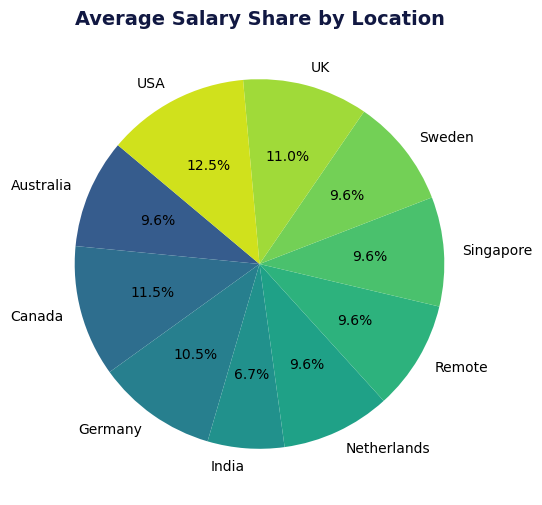

In [25]:
plt.figure(figsize=(11,6))
plt.pie(location_stats['salary'],
        labels=location_stats['location'],
        autopct='%1.1f%%',
        colors=sns.color_palette(["#365C8D", "#2E6E8E", 
                   "#277F8E", "#21918C", "#1FA187", "#2DB27D", 
                   "#4AC16D", "#73D056", "#A0DA39", "#D0E11C"], len(location_stats)),
        startangle=140)

plt.title("Average Salary Share by Location", fontsize=14, color='#111842', weight='bold')
plt.show()

#### 💡 Insight
- The USA, Canada, and UK contribute the largest shares of average salary, reflecting strong compensation markets in these regions.  
- Sweden, Singapore, Netherlands, and Australia hold balanced mid‑range shares.  
- India shows a smaller proportion, highlighting regional disparities in salary distribution.  